<a href="https://colab.research.google.com/github/voronv27/projects-in-ai-and-ml/blob/main/Homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: NeuralNetwork Class

The dataset I chose for this homework is this [Online Payment Fraud Detection](https://www.kaggle.com/datasets/jainilcoder/online-payment-fraud-detection/data) dataset.

The problem I would like to solve is a classification problem, which detects whether a transaction is legitimate (isFraud=0) or fraud (isFraud=1).

In [1]:
import pandas as pd

path = 'onlinefraud.csv'

data = pd.read_csv(path)
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


Here is my implementation of the NeuralNetwork class:

In [2]:
import numpy as np

class NeuralNetwork:
  # initialization
  def __init__(self, layers, alpha=0.01):
    self.layers = layers
    self.alpha = alpha
    self.W = []
    self.b = []

    # initialize relu layers
    for i in range(len(layers) - 1):
      # initialize random 2d array of w
      # use He initialization (multiply by sqrt(2/number of inputs))
      w = np.random.randn(layers[i], layers[i + 1]) * np.sqrt(2 / layers[i])
      self.W.append(w)

      # initialize b as 0s
      b = np.zeros((1, layers[i + 1]))
      self.b.append(b)

  def relu(self, z):
    # relu(z) = z if z > 0 else 0
    return np.maximum(0, z)

  def relu_deriv(self, z):
    # deriv of relu(z) = deriv(z)=1 if z > 0, else deriv(0)=0
    return (z > 0).astype(float)

  def sigmoid(self, z):
    # sigmoid(z) = 1 / (1 + e^(-z))
    z = np.clip(z, -500, 500) # avoid overflow error on exp(-z)
    return 1 / (1 + np.exp(-z))

  def sigmoid_deriv(self, a):
    # deriv of sigmoid(z) = sigmoid(z)(1 - sigmoid(z))
    # pass in a=sigmoid(z)
    return a * (1-a)

  # cost method (calculate loss)
  def cost(self, y, y_pred):
    eps = 1e-12
    loss = -np.mean(y * np.log(y_pred + eps) +
             (1 - y) * np.log(1 - y_pred + eps))
    return loss

  # forward propagation method
  def forward(self, x):
    Z = []
    A = [x]
    a = x

    # hidden layer computation
    for i in range (len(self.W) - 1):
      z = a @ self.W[i] + self.b[i]
      a = self.relu(z)
      Z.append(z)
      A.append(a)

    # output layer
    z = a @ self.W[-1] + self.b[-1]
    a = self.sigmoid(z)
    Z.append(z)
    A.append(a)

    return Z, A

  # backward propagation method
  def backward(self, A, Z, y):
    dW = []
    db = []

    # compute gradient for output layer
    # dL/dz = dL/da * da/dz for sigmoid + cross entropy
    dZ = A[-1] - y

    # partial derivatives of cost wrt parameters feeding into output layer
    # dW(l) = dZ(l)a(l-1)
    # db(l) = dZ(l)
    # divide by y.shape[0] to get average
    dW.append(A[-2].T @ dZ / y.shape[0])
    db.append(np.sum(dZ, axis=0, keepdims=True) / y.shape[0])

    # repeatedly find derivs until reach input layer
    for i in range(len(self.W) - 2, -1, -1):
      # dZ(l) = dA(l) * g'(Z(l))
      # dA(l) = dZ(l+1)W(l+1)^T
      dZ = dZ @ self.W[i + 1].T * self.relu_deriv(Z[i])

      # partial derivatives of cost wrt parameters feeding into current layer
      dW.insert(0, A[i].T @ dZ / y.shape[0])
      db.insert(0, np.sum(dZ, axis=0, keepdims=True) / y.shape[0])

    return dW, db

  # train method--use minibatch gradient descent
  # to speed up execution
  def fit(self, x, y, epochs=1000, batch=128):
    for ep in range(epochs):
      # shuffle data
      shuffle = np.random.permutation(x.shape[0])
      x_shuffle = x[shuffle]
      y_shuffle = y[shuffle]

      for b in range(0, x.shape[0], batch):
        x_batch = x_shuffle[b:b + batch]
        y_batch = y_shuffle[b:b + batch]

        # forward propagation
        Z, A = self.forward(x_batch)

        # backpropagation
        dW, db = self.backward(A, Z, y_batch)

        # update params via gradient descent
        for i in range(len(self.W)):
          self.W[i] -= self.alpha * dW[i]
          self.b[i] -= self.alpha * db[i]

  # predict method
  def predict(self, x):
    _, A = self.forward(x)
    return (A[-1] > 0.5).astype(int)

Now we test this NeuralNetwork class with the selected dataset.

In [3]:
# preprocess data
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# separate features (x) from label (y)
label_col = "isFraud"
assert label_col in data.columns, f"Label column {label_col} not in data"

# the nameOrig/Dest columns are identifiers, drop them
# we also need to drop them to avoid one-hot encoding
# a ton of columns since they are unique strings
x = data.drop(columns=[label_col, 'nameOrig', 'nameDest'])
y = data[label_col]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, train_size=10000, stratify=y, random_state=42
)

num_cols = [c for c in x_train.columns if x_train[c].dtype != 'object']
cat_cols = [c for c in x_train.columns if x_train[c].dtype == 'object']

numeric_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop='first', sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_cols),
        ("cat", categorical_tf, cat_cols)
    ]
)

x_train = preprocess.fit_transform(x_train)
x_test = preprocess.transform(x_test)

# convert y into 2d array as needed for my implementation
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

In [4]:
# train NeuralNetwork nn on our data
nn = NeuralNetwork([x_train.shape[1], 16, 8, 1])
nn.fit(x_train, y_train)

I used minibatch gradient descent in my NeuralNetwork model to speed up runtime, and used my default batch size of 128 for nn (and default epochs of 1000 for nn as well). I also took a subset of my training data (10000 values) for the same reason of improving runtime.

I chose to use minibatch gradient descent as it has less "jumps" than stochastic but performs more quickly than vanilla, meaning it has the "best of both worlds" between those two types of gradient descent. I took a subset of my training data because even with minibatch gradient descent (and using a smaller amount of 500 epochs in my initial testing), my model still took a really long time to run. There was just too much data in the dataset, and 10000 is still a large sampling of training data that I was confident my model could train on.

Finally, I made sure to use stratify=y when splitting my data into train and test since the data is more skewed towards non-fraud than fraud and the train and test data should have equal ratios for this skew.

In [5]:
# evaluate model
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
y_pred = nn.predict(x_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"f1-score: {f1_score(y_test, y_pred):.4f}")

Accuracy: 0.9987
Precision: 0.0000
Recall: 0.0000
f1-score: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Looking at these results, the model is very accurate, but the f1-score is not great due to low recall. Recall is the measure of predicted true positives (TP) divided by all actual positives (TP+FN). So this model predicts a lot of false negatives. This makes sense with the skew of the data--most datapoints are 0 (not fraud) so the model learns to predict fraud less often, leading to more false negatives.

#Part 2: Implement 2-layer Neural Network

## Task 1: Research Framework

I decided to use Pytorch to implement my 2-layer neural network. Looking at online resources, I can have my neural network class inherit from `torch.nn.Module`. I will implement my own forward propagation function `forward` which overwrites the default method and will be called when the model is given an input. In the init method, for the model, I need to set up my layers, which are a set of modules in `nn.Sequential`. `nn.Linear` represents a linear transformation and `nn.ReLU` is a ReLu transformation. `nn.Sigmoid` applies the sigmoid function, which we will do to our output layer.

Resources:

[1](https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html)
[2](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html)
[3](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)
[4](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
[5](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html)

##Task 2: Implement Project

###Exploratory Data Analysis

I already did some data cleaning in part 1 by removing some columns with IDs (leakage) in my `x`, but here we will take a closer look at the data, so we can preprocess it better in the next step.

In [6]:
print("(rows, columns):", data.shape)
data.info()

(rows, columns): (6362620, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
# our data is skewed, a lot more non-fraud than fraud cases
data['isFraud'].value_counts(normalize=True)

,proportion
isFraud,
0,0.998709
1,0.001291


In [8]:
# look at where we have missing values--we see none
data.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


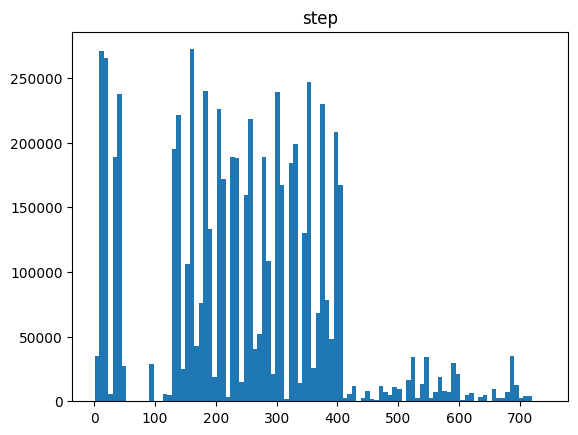

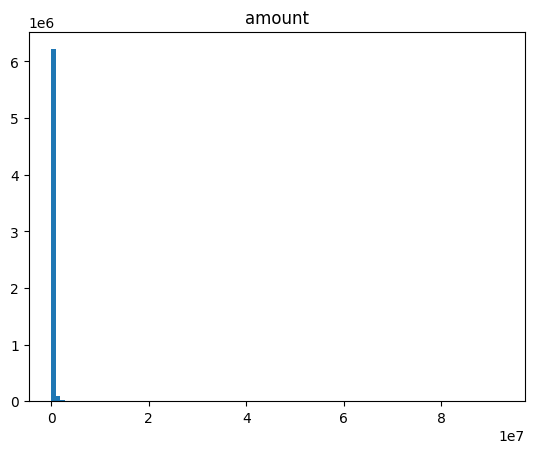

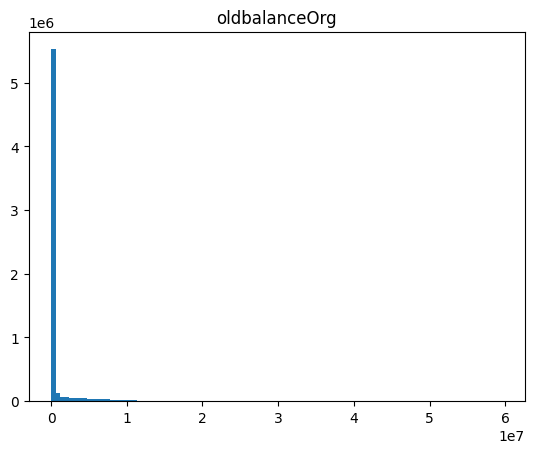

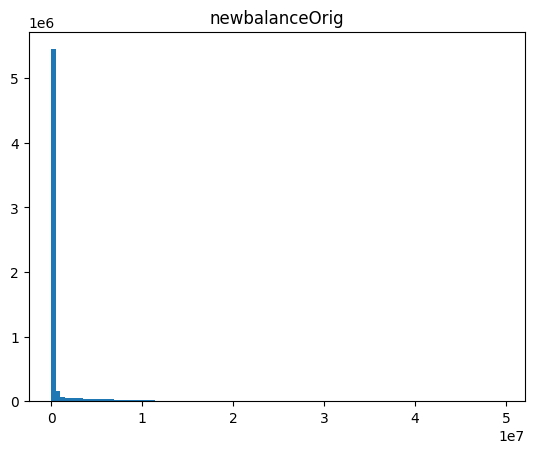

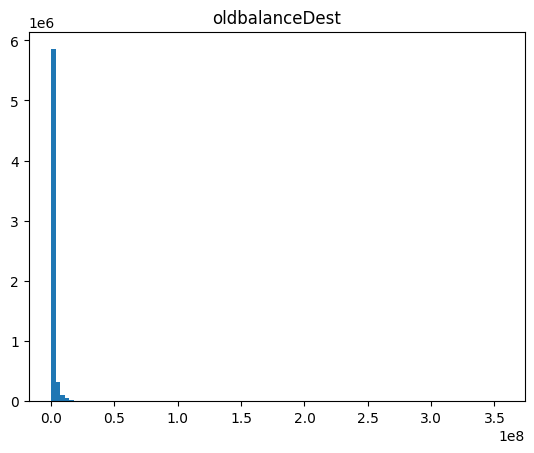

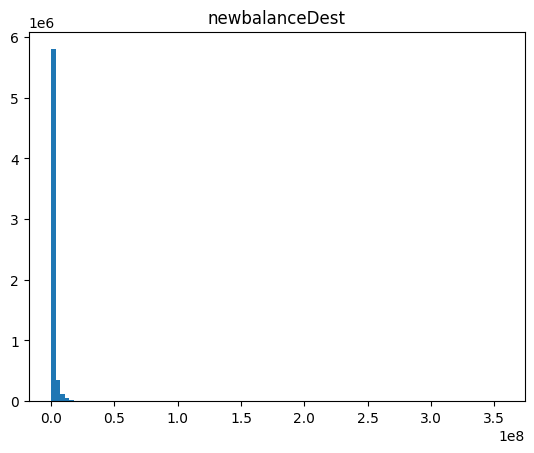

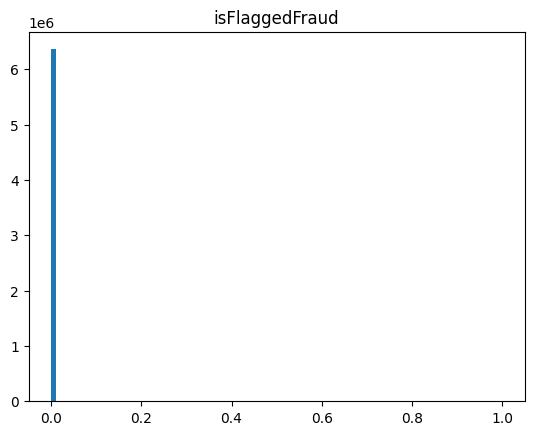

In [9]:
# examine distribution of numeric features
import matplotlib.pyplot as plt

for col in num_cols:
  plt.hist(data[col], bins=100)
  plt.title(col)
  plt.show()

We see that our numerical data is very skewed in most cases, with a few large outliers and most values concentrated in the "left" bins on the histograms.

Leakage analysis: we removed nameOrig and nameDest earlier as they were identifiers (leakage risk). I kept isFlaggedFraud in my model above, as it isn't technically leakage (it says if the system flags the transaction as fraud, but that doesn't rely on data from the isFraud column). That being said, I believe it may be better to remove it in this task so that my model isn't reliant on another system's predictions. The goal I stated above is to create a model which can detect whether a transaction is legitimate or not, and requiring another system/model to flag a transaction as fraud/not fraud before this model can make a prediction doesn't feel true to that goal.

For step, it might be good to transform this value into an hour of the day, since fraud could be more common at certain hours. To test this, I plotted the fraud per hour of the day:

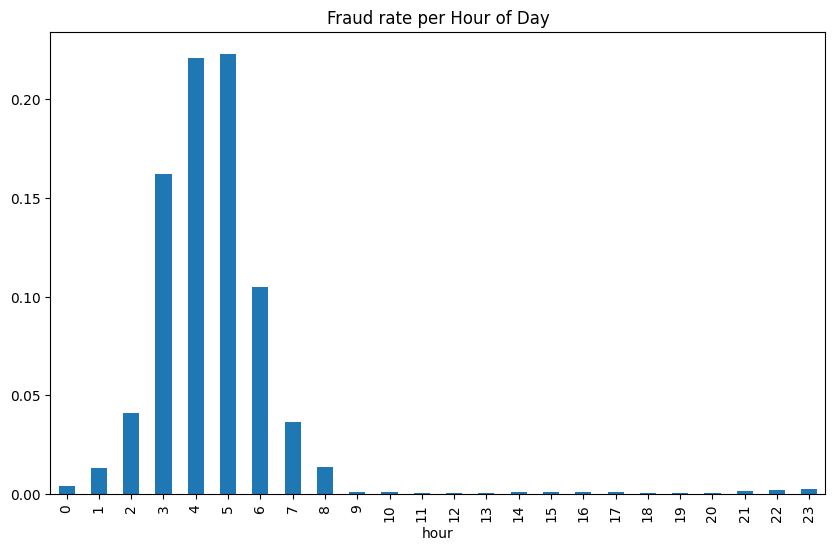

In [10]:
data['hour'] = data['step'] % 24
fraud_by_hour = data.groupby("hour")["isFraud"].mean()

plt.figure(figsize=(10, 6))
fraud_by_hour.plot(kind='bar')
plt.title("Fraud rate per Hour of Day")
plt.show()

There is a clear link between certain hours of the day and fraud, so we will use this instead of the raw "step" column to train our data.

###Train/Dev/Test Split

Let us split our data into train/dev/test (70/15/15 split) and preprocess it:

In [11]:
# separate features (x) from label (y)
label_col = "isFraud"
assert label_col in data.columns, f"Label column {label_col} not in data"

# the nameOrig/Dest columns are identifiers, drop them
# we also need to drop them to avoid one-hot encoding
# a ton of columns since they are unique strings
# NEW: drop step as we are using new 'hour' column
# NEW: drop 'isFlaggedFraud'
x = data.drop(columns=[label_col, 'nameOrig', 'nameDest', 'step', 'isFlaggedFraud'])
y = data[label_col]

# split train from dev+test
# take a subset for runtime purposes, 14000 vs 6000 is a 70/30 ratio
x_train, x_dev_test, y_train, y_dev_test = train_test_split(
    x, y, train_size=14000, test_size=6000, stratify=y, random_state=42
)

# split dev from train
x_dev, x_test, y_dev, y_test = train_test_split(
    x_dev_test, y_dev_test, test_size=0.5, stratify=y_dev_test, random_state=42
)

In [12]:
# preprocessing
from sklearn.preprocessing import FunctionTransformer

num_cols = [c for c in x_train.columns if x_train[c].dtype != 'object']
cat_cols = [c for c in x_train.columns if x_train[c].dtype == 'object']

# NEW: we see a lot of numeric columns have skew, so we can
# apply a log transform on those columns
log_transformer = FunctionTransformer(np.log1p)
skewed_cols = x_train[num_cols].skew()[x_train[num_cols].skew() > 1].index
non_skewed_cols = [c for c in num_cols if c not in skewed_cols]

skewed_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("scaler", StandardScaler())
])

non_skewed_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_tf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop='first', sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("skewed_num", skewed_tf, skewed_cols),
        ("num", non_skewed_tf, non_skewed_cols),
        ("cat", categorical_tf, cat_cols)
    ]
)

x_train = preprocess.fit_transform(x_train)
x_dev = preprocess.transform(x_dev)
x_test = preprocess.transform(x_test)

###Implement Forward Propagation

Inside the `TwoLayerNeuralNetwork` class itself, the only hyperparameter I have is `hidden_size`, which is the size of the hidden layer. However, I will have more hyperparameters in the gradient descent step with epochs, batch size, learning rate, and optimizer hyperparameters. I will discuss those hyperparameters when they come up as well as in task 3, where I explain how I selected them.

The activation functions I use are ReLU on the hidden layer and sigmoid on the output layer. The ReLu function is a non-linear transformation, which transforms the input by setting negative values to 0 (which helps with the vanishing gradient problem since the gradient is 1 for positive inputs). Sigmoid transforms our output to a value between 0 and 1, which we need for our binary classification problem.

I use these activation functions in `self.forward`, which is my forward propagation method.

In [13]:
import torch
import torch.nn as nn

class TwoLayerNeuralNetwork(nn.Module):
  def __init__(self, input_size, hidden_size=16):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(input_size, hidden_size), # hidden layer
        nn.ReLU(),                          # hidden layer
        nn.Linear(hidden_size, 1),          # output layer
        nn.Sigmoid()                        # output layer
    )

  def forward(self, x):
    return self.layers(x)

###Compute Final Cost Function

The `nn` module has a built-in binary cross-entropy loss function `nn.BCELoss` which we can use for this ([source](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCELoss.html))

###Implement Gradient Descent To Train Model

Note: our input data is normalized by scaling as part of our preprocessing. If we did not scale, we would see much worse performance--there are really large values in some of our columns such as amount and without scaling these features would dominate over other features with smaller values (such as the hour of the day, which will always be less than 24).

In [14]:
# convert data to pytorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
x_dev_tensor = torch.tensor(x_dev, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)

y_train_tensor = torch.tensor(np.asarray(y_train, dtype=np.float32)).reshape(-1, 1)
y_dev_tensor = torch.tensor(np.asarray(y_dev, dtype=np.float32)).reshape(-1, 1)
y_test_tensor = torch.tensor(np.asarray(y_test, dtype=np.float32)).reshape(-1, 1)

In [15]:
# function to initialize model (so we can test different hyperparams)
def initialize_model(input_size, hidden_size=16, lr=0.01):
  model = TwoLayerNeuralNetwork(input_size, hidden_size)
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  loss_fn = nn.BCELoss()
  return model, optimizer, loss_fn

In [16]:
# function to run batch gradient descent (so we can test different hyperparams)
def train_model(model, optimizer, loss_fn, epochs=50, batch_size=128, print_step=10):
  for ep in range(epochs):
    model.train() # put model in training mode

    # shuffle data
    shuffle = np.random.permutation(x_train_tensor.shape[0])
    x_shuffle = x_train_tensor[shuffle]
    y_shuffle = y_train_tensor[shuffle]

    # minibatch gradient descent
    for b in range(0, x_train_tensor.shape[0], batch_size):
      x_batch = x_shuffle[b:b + batch_size]
      y_batch = y_shuffle[b:b + batch_size]

      optimizer.zero_grad() # zero gradients
      y_pred = model(x_batch) # forward propagation
      loss = loss_fn(y_pred, y_batch) # compute loss
      loss.backward() # backward propagation
      optimizer.step() # update weights

    # evaluate on dev set
    model.eval() # put model in evaluation mode
    with torch.no_grad():
      y_pred = model(x_dev_tensor)
      loss = loss_fn(y_pred, y_dev_tensor)

    if print_step and (ep % print_step == 0):
        print(f"Epoch {ep}, Loss: {loss.item()}")

In [17]:
# initial run
model, optimizer, loss_fn = initialize_model(x_train.shape[1])
train_model(model, optimizer, loss_fn)

model.eval()
with torch.no_grad():
  y_pred = model(x_dev_tensor)
  y_pred = (y_pred > 0.5).float()

  accuracy = accuracy_score(y_dev_tensor, y_pred)
  precision = precision_score(y_dev_tensor, y_pred)
  recall = recall_score(y_dev_tensor, y_pred)
  f1 = f1_score(y_dev_tensor, y_pred)
  loss = loss_fn(y_pred, y_dev_tensor)

  print()
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"f1-score: {f1:.4f}")
  print(f"Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.009204445406794548
Epoch 10, Loss: 0.00269377906806767
Epoch 20, Loss: 0.002306274138391018
Epoch 30, Loss: 0.0017894170014187694
Epoch 40, Loss: 0.0020194165408611298

Accuracy: 0.9997
Precision: 1.0000
Recall: 0.7500
f1-score: 0.8571
Loss: 0.0333


We will test different hyperparameters to find the best ones. I am using random search for this to test a spread of hyperparameter combinations more quickly than grid search.

In [18]:
hidden_sizes=[8, 16, 32]
learning_rates = [0.01, 0.005, 0.001]
batch_sizes = [64, 128, 256]
num_epochs = [50, 100, 150]
results = []

for i in range(10):
  # randomly pick parameters
  hidden_size = np.random.choice(hidden_sizes)
  lr = np.random.choice(learning_rates)
  batch = np.random.choice(batch_sizes)
  ep = np.random.choice(num_epochs)

  # train model
  model, optimizer, loss_fn = initialize_model(x_train.shape[1], hidden_size, lr)
  train_model(model, optimizer, loss_fn, ep, batch, print_step=None)

  # evaluate model
  model.eval()
  with torch.no_grad():
    y_pred = model(x_dev_tensor)
    y_pred = (y_pred > 0.5).float()
    f1 = f1_score(y_dev_tensor, y_pred)
    results.append((hidden_size, lr, ep, batch, f1))
    print(f"hidden_size: {hidden_size}, lr: {lr}, epochs: {ep}, batch_size: {batch}, f1-score: {f1}")

# maximize f1-score
best_params = max(results, key=lambda x: x[4])
hidden_size, lr, ep, batch, f1 = best_params
print()
print(f"Best parameters: hidden_size: {hidden_size}, lr: {lr}, epochs: {ep}, batch_size: {batch}, f1-score: {f1}")

hidden_size: 8, lr: 0.01, epochs: 50, batch_size: 64, f1-score: 0.8571428571428571
hidden_size: 8, lr: 0.01, epochs: 50, batch_size: 64, f1-score: 0.8571428571428571
hidden_size: 8, lr: 0.001, epochs: 100, batch_size: 128, f1-score: 0.75
hidden_size: 32, lr: 0.01, epochs: 50, batch_size: 64, f1-score: 0.8571428571428571
hidden_size: 8, lr: 0.005, epochs: 100, batch_size: 256, f1-score: 0.75
hidden_size: 8, lr: 0.01, epochs: 150, batch_size: 256, f1-score: 0.8571428571428571
hidden_size: 32, lr: 0.005, epochs: 50, batch_size: 64, f1-score: 0.8571428571428571
hidden_size: 32, lr: 0.005, epochs: 50, batch_size: 64, f1-score: 0.8571428571428571
hidden_size: 16, lr: 0.001, epochs: 50, batch_size: 128, f1-score: 0.75
hidden_size: 16, lr: 0.01, epochs: 100, batch_size: 256, f1-score: 0.8571428571428571

Best parameters: hidden_size: 8, lr: 0.01, epochs: 50, batch_size: 64, f1-score: 0.8571428571428571


###Present Results

Now that we have the best hyperparameters, let us train the model with those hyperparameters and then see how it performs on the test dataset.

In [33]:
# train model
hidden_size = 8
lr = 0.01
ep = 50
batch = 64
model, optimizer, loss_fn = initialize_model(x_train.shape[1], hidden_size, lr)
train_model(model, optimizer, loss_fn, ep, batch, print_step=20)

# evaluate model
model.eval()
with torch.no_grad():
  y_pred = model(x_test_tensor)
  y_pred = (y_pred > 0.5).float()

  # various metrics
  accuracy = accuracy_score(y_test_tensor, y_pred)
  precision = precision_score(y_test_tensor, y_pred)
  recall = recall_score(y_test_tensor, y_pred)
  f1 = f1_score(y_test_tensor, y_pred)
  loss = loss_fn(y_pred, y_test_tensor)

  print()
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"f1-score: {f1:.4f}")
  print(f"Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.006692846771329641
Epoch 20, Loss: 0.0024907609913498163
Epoch 40, Loss: 0.0021271705627441406

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
f1-score: 1.0000
Loss: 0.0000


Here we see the final results on the test data. We have managed to get perfect performance, which feels a bit unrealistic. Just to make sure that our test dataset has fraud cases (it should since we set stratify=y), I ran the following:

In [34]:
print("test data isFraud 0 to 1 counts:", np.bincount(y_test))

test data isFraud 0 to 1 counts: [2996    4]


This is an about right distribution for our dataset, we have a lot more non-fraud than fraud cases and that is reflected in the test data as well. Moreover, for those fraud cases, the model does predict them as fraud correctly rather than defaulting to always predicting non-fraud.

##Task 3: Explain Hyperparameter Selection

The method I used to select my final hyperparameters in task 2 was random search. The reasoning behind this was that I could more quickly test different combinations of hyperparameters than performing a grid search, and with less personal bias than if I were to just go with my instinct in selecting them.

I picked my "best" model by maximizing f1-score across all the random combinations of hyperparamters I tried. My goal for this model is to predict fraud, which means being able to properly predict both fraud/non-fraud cases. In this dataset, most cases are not fraud. However, my model should be able to predict fraud accurately when it does occur, rather than just predicting non-fraud for everything due to the skewed dataset it was trained on. This means I need to optimize recall to ensure it isn't predicting too many false negatives. Of course, I also want to ensure there aren't many false positives, so precision is also important. This is why I optimized f1-score--it takes both precision and recall into account.

I used the Adam optimization algorithm as a way to speed up my gradient descent while still having stable convergence. An optimizer will mean that less epochs are needed to train the model, which improves runtime. The Adam algorithm in particular is widely used since it combines the techniques in the Momentum and RMSProp optimizers. It adjusts the learning rate based on past gradients to speed up training and reduce noise/bounce. Overall, Adam has consistent efficient performance and doesn't require a lot of configuration, which is why I chose it.

I did not use any regularization. My neural network complexity is fairly small compared to the size of my training data, which is very large. I didn't believe that regularization would be critical as the model isn't likely to be overfitting, which is what regularization is meant to fix.

##Task 4 (Graduate Level): Compare NN Model to Baseline Model

I will compare to a Decision Tree Classifier model.

In [29]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier()

# Fit the model directly on the preprocessed x_train
model_dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [30]:
y_pred = model_dt.predict(x_test)

# various metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"f1-score: {f1:.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
f1-score: 1.0000


Again, we see "perfect performance" for the test set. It is possible that somehow, through pure random chance, the best possible test set was selected (really easy-to-identify fraud cases) that both models could excel at. So, though it is a bit unfair of a comparison for the decision tree model, which was not optimized on x_dev while the neural network was optimized based on its performance on x_dev, I will compare the performance of the two models on x_dev as well so we can see non-perfect metrics.

In [35]:
# neural network
model.eval()
with torch.no_grad():
  y_pred = model(x_dev_tensor)
  y_pred = (y_pred > 0.5).float()

  # various metrics
  accuracy = accuracy_score(y_dev_tensor, y_pred)
  precision = precision_score(y_dev_tensor, y_pred)
  recall = recall_score(y_dev_tensor, y_pred)
  f1 = f1_score(y_dev_tensor, y_pred)

  print("Neural Network Metrics")
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"f1-score: {f1:.4f}")

Neural Network Metrics
Accuracy: 0.9997
Precision: 1.0000
Recall: 0.7500
f1-score: 0.8571


In [36]:
# decision tree
y_pred = model_dt.predict(x_dev)

# various metrics
accuracy = accuracy_score(y_dev, y_pred)
precision = precision_score(y_dev, y_pred)
recall = recall_score(y_dev, y_pred)
f1 = f1_score(y_dev, y_pred)

print("Decision Tree Metrics")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"f1-score: {f1:.4f}")

Decision Tree Metrics
Accuracy: 0.9997
Precision: 1.0000
Recall: 0.7500
f1-score: 0.8571


We see that the model's metrics are the exact same. Here I'm seeing if they made the exact same predictions:

In [41]:
model.eval()
with torch.no_grad():
  y_pred_nn = model(x_dev_tensor)
  y_pred_nn = (y_pred_nn > 0.5).float().numpy().flatten()

  y_pred_dt = model_dt.predict(x_dev)
  print("Same predictions?", np.array_equal(y_pred_nn, y_pred_dt))



Same predictions? True


The two models made the exact same predictions! Since the recall is < 1 while precision == 1, we can see that they both predicted the same false negatives (both models failed to identify the same cases as fraud). This is really interesting behavior.

Most likely, we see this behavior because there are so few fraud cases. Both models learn very similar patterns for detecting fraud when it occurs, and there are so few fraud cases that their predictions happen to be the same for the few that occur.

If I were to redo this problem and take a larger sampling of fraud cases, as opposed to staying true to the skew in the dataset, we would probably see more significant differences between these two models. As is, I just find it really interesting that for the right dataset, two different models can come to the exact same conclusions.